# 8-4 진짜 VGGNet과 ResNet 활용해 보기

본 노트북은 8-4 절 본문의 [코드 8-13]~[코드 8-16] 예제를 포함한다. 허깅페이스 허브에 등록된 사전 학습 모델을 timm 라이브러리로 내려받아 예측에 쓰고, ResNet-50 을 흉부 X선 사진 분류에 전이 학습한다.

다루는 내용
- `[코드 8-13]` timm 으로 VGGNet-16 모델을 내려받아 이미지 분류
- `[코드 8-14]` ResNet-50 에 맞는 흉부 X선 데이터의 데이터셋·데이터로더
- `[코드 8-15]` ResNet-50 모델 구조 확인
- `[코드 8-16]` 특징 추출 방식 전이 학습을 위한 분류기 계층 교체와 학습

> 사전 학습 모델 가중치와 흉부 X선 데이터셋(약 2.3GB)은 외부에서 내려받는다. timm 모델·ImageNet 레이블·캐글 데이터셋 다운로드가 환경에 따라 실패할 수 있어, 실패 시 동작을 이어가도록 분기를 두었다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

8장 전이 학습 예제는 timm, kagglehub 가 추가로 필요하다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q kagglehub pillow requests timm

## 라이브러리 import 와 시드 고정

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
# import copy
# import time
# import random

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from pathlib import Path
# import requests
# import timm
# from PIL import Image
# from torch.utils.data import DataLoader
# from torchvision.datasets import ImageFolder

SEED = 42
common.set_seed(SEED)
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

device = common.get_device()

CUDA를 사용합니다.


## [코드 8-13] timm 라이브러리를 통해 VGGNet-16 모델을 사용하는 예시

`timm.create_model('vgg16_bn', pretrained=True)` 로 사전 학습된 VGGNet-16 을 내려받는다. 모델 설정으로부터 데이터 변환 객체를 만들어 테스트 이미지를 분류하고, 점수 상위 5개 그룹을 ImageNet 레이블로 보여 준다.

In [3]:
###############################################################################
# 코드 8-13 - timm 라이브러리를 통해 VGGNet-16 모델을 사용하는 예시
###############################################################################
import torch
from PIL import Image
import timm

# 테스트 이미지로 깃허브의 data/cat.jpg를 사용
data_root = '../../data'  
img = Image.open(data_root + '/cat.jpg')            # Pillow 객체

# timm.create_model() 을 사용해 파이토치 모델을 생성
# 모델의 참조 이름(vgg16_bn)은 timm 라이브러리 문서 참조
vggnet_16 = timm.create_model('vgg16_bn', pretrained=True).to(device)

# 모델 설정으로부터 데이터 변환 객체 만들기(Pillow 객체 -> 샘플 텐서 변환)
# ① 모델 설정(vggnet_16.default_cfg)에서 모델의 데이터 설정 정보 추출
config = vggnet_16.default_cfg
transform_config = timm.data.resolve_data_config(config)

# ② 데이터 설정 정보(transform_config)를 사용해 데이터 변환 객체 생성
#    딕셔너리를 언패킹 연산자(**)와 함께 인자로 전달
transform = timm.data.create_transform(**transform_config)

# 이미지의 분류 결과 예측
# 합성곱 신경망 계층 입력으로 사용하기 위한 배치 차원 추가
input_tensor = transform(img).unsqueeze(0).to(device)
# 모델을 사용해 예측
vggnet_16.eval()
with torch.no_grad():
    output = vggnet_16(input_tensor)
# 점수 기준 상위 5개 클래스를 선택(topk() 함수)
_, top5_idx = torch.topk(output, 5)

In [4]:
###############################################################################
# 코드 8-13 - timm 라이브러리를 통해 VGGNet-16 모델을 사용하는 예시 (계속)
###############################################################################
import requests

# top5_idx는 인덱스이며, 이 값이 실제 무엇인지(클래스 이름)는 별도 정보가 필요
# VGGNet 학습에 사용한 ImageNet 데이터셋의 레이블 정보를 가져와 사용
labels_url = (
    'https://raw.githubusercontent.com/pytorch/hub/master/'
    'imagenet_classes.txt'
)                           # ImageNet 클래스 레이블 정보 URL
try:
    labels = requests.get(labels_url, timeout=30).text.splitlines()
except Exception:
    # 다운로드 실패 시 torchvision의 ImageNet 카테고리로 대체
    from torchvision.models import ResNet50_Weights
    labels = ResNet50_Weights.DEFAULT.meta['categories']

for i in range(5):
    label_name = labels[top5_idx[0, i].item()]
    print(f'{i + 1}위: {label_name}')

1위: tiger cat
2위: Egyptian cat
3위: tabby
4위: lynx
5위: tiger


## 참고 - 흉부 X선 사진 데이터 다운로드

본문은 캐글의 흉부 X선 사진 데이터를 `kagglehub.dataset_download()` 로 받는다(압축 전 약 2.3GB, 디스크 공간 확인 필요). 환경에 따라 캐글 인증 등으로 실패할 수 있어, 실패 시 CIFAR-10 의 2개 클래스로 대체해 전이 학습 흐름을 그대로 시연한다.

In [ ]:
# 참고 - kagglehub에서 흉부 X선 데이터셋 내려받기
from pathlib import Path
import kagglehub

xray_root = data_root + '/kaggle/chest_xray/'
print('kagglehub로 chest-xray-pneumonia 데이터셋 다운로드 시도...')
# 약 2.3G의 데이터를 내려 받고, 압축 해제 과정을 거치므로 약 5G 정도의 디스크가 필요
# 미리 디스크 용량을 확인하고 진행하며, 실습 시점에 따라 데이터 사용 여부가 달라질 수 있음
path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia', output_dir=xray_root)

# 내려받은 후 train 디렉터리가 있는 경로를 확인
candidate = Path(path) / 'chest_xray'
xray_root = candidate if candidate.exists() else Path(path)
if (xray_root / 'train').exists():
    print(f'데이터셋 루트: {xray_root}')
else:
    print('데이터셋 루트에 train 디렉터리가 없습니다. 다운로드 실패 여부를 확인하세요.')

kagglehub로 chest-xray-pneumonia 데이터셋 다운로드 시도...


100%|██████████| 2.29G/2.29G [02:57<00:00, 13.9MB/s]

Extracting files...


데이터셋 루트: ../../data/kaggle/chest_xray/chest_xray


## [코드 8-14] ResNet-50 모델에 맞는 흉부 X선 데이터의 데이터셋과 데이터로더

ResNet-50 모델을 불러오고, 모델 설정으로 만든 데이터 변환 객체를 `ImageFolder` 에 적용해 데이터셋·데이터로더를 만든다. `ImageFolder` 는 클래스별 디렉터리의 이미지로 데이터셋을 만들고 디렉터리 이름을 0, 1, ... 레이블로 자동 매핑한다.

In [21]:
common.set_seed(SEED)

42

In [22]:
###############################################################################
# 코드 8-14 - ResNet-50 모델에 맞는 흉부 X선 데이터의 데이터셋과 데이터로더
###############################################################################
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# xray_data_path: 흉부 X선 데이터셋의 루트 디렉터리(data/kaggle/chest_xray/)
# Pathlib.Path 방식으로 경로를 처리
train_path = xray_root / 'train'    # 훈련 데이터 이미지 디렉터리
valid_path = xray_root / 'val'      # 검증 데이터 이미지 디렉터리
test_path = xray_root / 'test'      # 평가 데이터 이미지 디렉터리

# ResNet-50 모델 불러오기
model = timm.create_model('resnet50', pretrained=True)

# 모델 설정으로부터 데이터 변환 객체 생성
config = model.default_cfg
transform_config = timm.data.resolve_data_config(config)
transform = timm.data.create_transform(**transform_config)

# torchvision.datasets.ImageFolder: 지정 디렉터리의 이미지로 데이터셋을 생성
#     입력: 이미지(transform 적용)
#     정답: 레이블 (하위 디렉터리별로 0, 1, ... 자동 생성)
train_set = ImageFolder(root=train_path, transform=transform)
valid_set = ImageFolder(root=valid_path, transform=transform)
test_set = ImageFolder(root=test_path, transform=transform)

print(f'훈련 데이터셋의 샘플 수: {len(train_set)}')   # 출력값: 5216
print(f'검증 데이터셋의 샘플 수: {len(valid_set)}')   # 출력값: 16
print(f'평가 데이터셋의 샘플 수: {len(test_set)}')    # 출력값: 624

# 데이터셋의 classes 속성: 디렉터리 이름(레이블로 사용 가능)
print(f'클래스: {train_set.classes}')       # 출력값: ['NORMAL', 'PNEUMONIA']

# 데이터로더 생성
BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


훈련 데이터셋의 샘플 수: 5216
검증 데이터셋의 샘플 수: 16
평가 데이터셋의 샘플 수: 624
클래스: ['NORMAL', 'PNEUMONIA']


## [코드 8-15] ResNet-50 모델 구조 확인

전이 학습 준비를 위해 계층의 변수명을 알아야 하므로 `torchinfo.summary()` 대신 `print(model)` 로 구조를 확인한다. 출력이 매우 길어 핵심 계층만 추려 보여 준다. 마지막 분류기(`fc`)는 입력 2048, 출력 1000 이다.

In [23]:
###############################################################################
# 코드 8-15 - ResNet-50 모델 구조 확인
###############################################################################
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True

## [코드 8-16] 특징 추출 방식의 전이 학습을 위한 ResNet-50의 분류기 계층 교체

특징 추출 방식이므로 모든 파라미터를 먼저 고정한 뒤 분류기(`fc`)를 출력 크기 2 인 새 선형 계층으로 교체한다. 교체 전에 일괄 고정하면 새 계층만 학습 대상이 된다. 교체 직후의 분류 정확도는 무작위 초기화된 새 계층 때문에 의미 없는 값이다.

In [24]:
# 참고 - 분류 정확도를 계산하는 함수
@torch.no_grad()
def get_accuracy(model, dataloader, device):
    model.eval()
    correct_size, sample_size = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return correct_size / sample_size

In [ ]:
###############################################################################
# 코드 8-16 - 특징 추출 방식의 전이 학습을 위한 ResNet-50 의 분류기 교체
###############################################################################
import torch.nn as nn

# 파라미터 고정: 사전 학습 모델의 추가 학습 방지(특징 추출 방식)
# 출력층 교체 이전에 파라미터를 고정해야 함 
#     : 순서가 바뀌면 학습해야 하는 출력층의 파라미터도 고정됨
for param in model.parameters():
    param.requires_grad = False

# 모델의 출력층(model.fc): 출력 크기가 2(정상/비정상)인 새 선형 계층으로 대체
model.fc = nn.Linear(2048, 2)

# 모델을 학습 장치로 보냄
model = model.to(device)

# 전이 학습 전 분류 정확도(get_accuracy(): 분류 정확도 계산 함수)
accuracy = get_accuracy(model, test_loader, device)
print(f'전이 학습 전 분류 정확도: {accuracy * 100:.2f}%')

전이 학습 전 분류 정확도: 59.62%


## 참고 - 특징 추출 방식 전이 학습

교체한 분류기 계층(`fc`)만 학습한다. 학습 과정은 다른 분류 모델과 같아 본문은 생략했지만, 노트북에서는 조기 종료 학습 루프로 실제 학습을 수행해 전이 학습 전후의 분류 정확도를 비교한다.

epoch    훈련 손실    검증 손실    정확도(%)     시간
 1/20       0.3639       0.4344       75.00%     1:17
 2/20       0.2251       0.4017       75.00%     2:38
 4/20       0.1742       0.3423       81.25%     5:23
 6/20       0.1536       0.3434       75.00%     8:06
 8/20       0.1442       0.3444       75.00%    10:47
10/20       0.1313       0.3679       87.50%    13:25
최적 에포크(5, 최소 검증 손실 0.3351)의 파라미터로 모델 복원


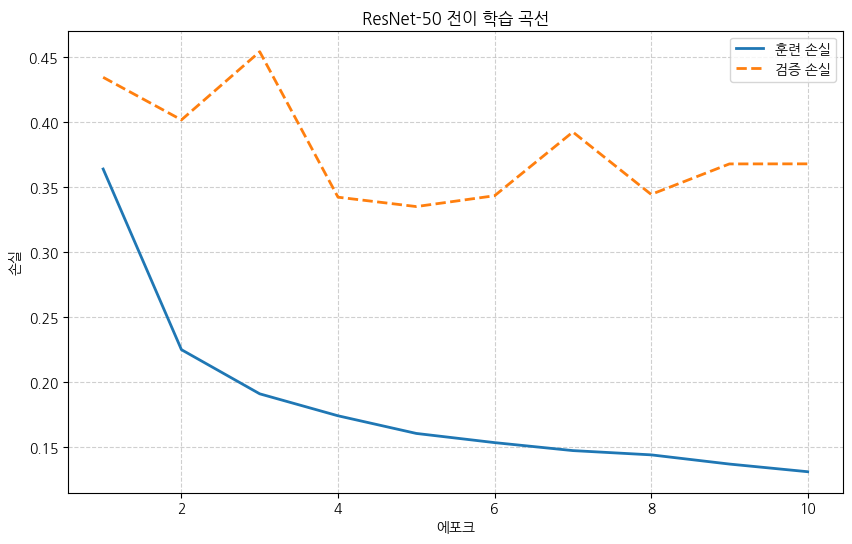

전이 학습 후 분류 정확도: 78.69%


In [26]:
# 참고 - 학습/검증 함수와 조기 종료 학습 루프 (정확도 포함)
import torch.optim as optim
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 검증 함수(손실과 분류 정확도 반환)
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 학습 환경 설정
EPOCHS = 20
PATIENCE = 5
LR = 1e-3
criterion = nn.CrossEntropyLoss()

# 특징 추출 방식: requires_grad=True 인 fc 파라미터만 최적화
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=LR,
)

# 학습 루프
# 학습 로거 설정
log = common.EpochLogger(EPOCHS)
# 조기 종료 판정을 위한 변수 초기화
best_valid_loss = float('inf')
best_model_params, best_epoch, patience_counter = None, 0, 0
best_epoch = -1
for epoch in range(1, EPOCHS + 1):
    # 최적화
    train_loss = train_epoch(
        model, train_loader, criterion, optimizer, device,
    )
    # 검증
    valid_loss, valid_acc = evaluate(
        model, valid_loader, criterion, device,
    )
    # 학습 로그 저장 및 출력
    log.row(epoch, train_loss, valid_loss, valid_acc * 100)
    # 조기 종료 판단
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_params = copy.deepcopy(model.state_dict())
        best_epoch = epoch
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:            
            break
# 최적 모델로 복원
if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)
# 학습 곡선 시각화
log.plot(title='ResNet-50 전이 학습 곡선')

# 전이 학습 후 분류 정확도
accuracy_after = get_accuracy(model, test_loader, device)
print(f'전이 학습 후 분류 정확도: {accuracy_after * 100:.2f}%')

## 정리

- 허깅페이스 허브는 수많은 공개 사전 학습 모델을 모아 둔 플랫폼이며, 비전 모델은 timm 라이브러리로 손쉽게 내려받아 쓸 수 있다.
- timm 은 모델뿐 아니라 모델 설정에 맞는 데이터 변환 객체(`resolve_data_config`·`create_transform`)도 함께 제공한다.
- 사전 학습 모델을 전이 학습에 쓰려면 새로운 목적에 맞게 분류기 계층을 교체해야 한다. 특징 추출 방식은 모든 파라미터를 고정한 뒤 교체한 계층만 학습한다.